In [15]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [16]:
class AgentState(TypedDict):
    num1 : int
    num2 : int
    operation : str
    message : str

In [17]:
def adder_node(state: AgentState)-> AgentState:
    """Addition node"""
    
    state['message'] = f"Number-1 is {state['num1']}. Number-2 is {state['num2']}. Addition is {state['num1']+state['num2']}"
    return state

def subtracter_node(state: AgentState)-> AgentState:
    """Subtraction node"""
    
    state['message'] = f"Number-1 is {state['num1']}. Number-2 is {state['num2']}. Subtruction is {state['num1']-state['num2']}"
    return state

def condition_node(state: AgentState)-> AgentState:
    """Conditional node to decide next node"""

    if state['operation']=='+':
        return "addition_operation"
    elif state['operation']=='-':
        return "subtraction_operation"

In [ ]:
graph = StateGraph(AgentState)

graph.add_node('condition', lambda state:state)
graph.add_node('addition', adder_node)
graph.add_node('subtraction', subtracter_node)

graph.add_edge(START, 'condition')
graph.add_conditional_edges(
    'condition',
    condition_node,
    {
        #---- Edge : Node  ---------
        "addition_operation": 'addition',
        "subtraction_operation": 'subtraction'
    }
)
graph.add_edge('addition', END)
graph.add_edge('subtraction', END)

app = graph.compile()

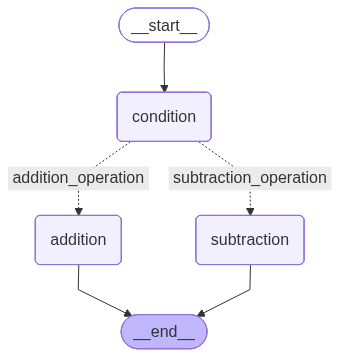

In [19]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
result = app.invoke({'num1': 5, 'num2':20, 'operation':'+'})

In [21]:
result['message']

'Number-1 is 5. Number-2 is 20. Addition is 25'